# 🦠 COVID-19 Trend Analysis with Python

**Objectives:**
- Visualize global and India COVID-19 trends (confirmed, deaths, recovered)
- Analyze infection and recovery rates
- Build a Prophet time-series model to forecast cases 7 days ahead

---


## 📦 Step 1 — Install & Import Libraries

In [ ]:
# Run this cell first (especially needed on Google Colab / fresh environments)
!pip install prophet plotly pandas numpy requests --quiet

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📥 Step 2 — Load COVID-19 Data

We fetch the **Johns Hopkins CSSE** dataset directly from GitHub — the same widely-used source referenced in data science COVID projects.

> **If you have your own CSV/Excel files**, replace the loading cells below with:
> ```python
> df = pd.read_csv('your_file.csv')   # or pd.read_excel('your_file.xlsx')
> ```

In [3]:
# ── Johns Hopkins CSSE time-series URLs ──────────────────────────────────────
BASE = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/"

urls = {
    'confirmed': BASE + 'time_series_covid19_confirmed_global.csv',
    'deaths'   : BASE + 'time_series_covid19_deaths_global.csv',
    'recovered': BASE + 'time_series_covid19_recovered_global.csv',
}

raw = {}
for key, url in urls.items():
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        raw[key] = pd.read_csv(StringIO(r.text))
        print(f'✅ Loaded {key}: {raw[key].shape}')
    except Exception as e:
        print(f'⚠️  Could not fetch {key} — {e}')
        print('   → Using synthetic demo data instead.')
        raw[key] = None

✅ Loaded confirmed: (289, 1147)


✅ Loaded deaths: (289, 1147)


✅ Loaded recovered: (274, 1147)


In [4]:
# ── Synthetic fallback (used if network is unavailable) ──────────────────────
def make_synthetic():
    """Generate realistic-looking synthetic COVID data for demo purposes."""
    dates = pd.date_range('2020-01-22', periods=700, freq='D')
    np.random.seed(42)

    def epidemic_curve(peak_day, peak_val, n=700):
        x = np.arange(n)
        base = peak_val * np.exp(-0.5 * ((x - peak_day) / 120) ** 2)
        noise = np.random.normal(0, peak_val * 0.02, n)
        return np.maximum(0, base + noise).cumsum()

    global_conf = epidemic_curve(300, 800_000)
    global_dth  = global_conf * np.random.uniform(0.01, 0.025, 700)
    global_rec  = global_conf * np.random.uniform(0.60, 0.85, 700)

    india_conf  = epidemic_curve(350, 300_000) * 0.15
    india_dth   = india_conf  * np.random.uniform(0.008, 0.015, 700)
    india_rec   = india_conf  * np.random.uniform(0.65, 0.88, 700)

    return pd.DataFrame({
        'date'            : dates,
        'global_confirmed': global_conf.astype(int),
        'global_deaths'   : global_dth.astype(int),
        'global_recovered': global_rec.astype(int),
        'india_confirmed' : india_conf.astype(int),
        'india_deaths'    : india_dth.astype(int),
        'india_recovered' : india_rec.astype(int),
    })

USE_SYNTHETIC = any(v is None for v in raw.values())
if USE_SYNTHETIC:
    print('ℹ️  Using synthetic data for all cells below.')
    synth = make_synthetic()
else:
    synth = None

print('✅ Fallback ready.')

✅ Fallback ready.


In [5]:
# ── Melt JHU wide format → long format ───────────────────────────────────────
def melt_jhu(df, value_name):
    id_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
    date_cols = [c for c in df.columns if c not in id_cols]
    melted = df.melt(id_vars=id_cols, value_vars=date_cols,
                     var_name='date', value_name=value_name)
    melted['date'] = pd.to_datetime(melted['date'])
    return melted

if not USE_SYNTHETIC:
    conf_long = melt_jhu(raw['confirmed'], 'confirmed')
    dth_long  = melt_jhu(raw['deaths'],    'deaths')
    rec_long  = melt_jhu(raw['recovered'], 'recovered')

    # ── Global daily totals ───────────────────────────────────────────────────
    def global_daily(df, col):
        return df.groupby('date')[col].sum().reset_index()

    g_conf = global_daily(conf_long, 'confirmed')
    g_dth  = global_daily(dth_long,  'deaths')
    g_rec  = global_daily(rec_long,  'recovered')

    global_df = g_conf.merge(g_dth, on='date').merge(g_rec, on='date')

    # ── India data ────────────────────────────────────────────────────────────
    def country_daily(df, col, country='India'):
        mask = df['Country/Region'] == country
        return df[mask].groupby('date')[col].sum().reset_index()

    i_conf = country_daily(conf_long, 'confirmed')
    i_dth  = country_daily(dth_long,  'deaths')
    i_rec  = country_daily(rec_long,  'recovered')

    india_df = i_conf.merge(i_dth, on='date').merge(i_rec, on='date')

    print(f'Global rows : {len(global_df)}')
    print(f'India  rows : {len(india_df)}')
else:
    global_df = synth[['date','global_confirmed','global_deaths','global_recovered']].rename(
        columns={'global_confirmed':'confirmed','global_deaths':'deaths','global_recovered':'recovered'})
    india_df = synth[['date','india_confirmed','india_deaths','india_recovered']].rename(
        columns={'india_confirmed':'confirmed','india_deaths':'deaths','india_recovered':'recovered'})

# ── Derived columns ───────────────────────────────────────────────────────────
for df in [global_df, india_df]:
    df['active']        = df['confirmed'] - df['deaths'] - df['recovered']
    df['daily_new']     = df['confirmed'].diff().fillna(0).clip(lower=0)
    df['recovery_rate'] = (df['recovered'] / df['confirmed'].replace(0, np.nan) * 100).round(2)
    df['fatality_rate'] = (df['deaths']    / df['confirmed'].replace(0, np.nan) * 100).round(2)

print('\n📋 Global tail:')
global_df.tail(3)

Global rows : 1143
India  rows : 1143

📋 Global tail:


,date,confirmed,deaths,recovered,active,daily_new,recovery_rate,fatality_rate
1140,2023-03-07,676213378,6879038,0,669334340,130437.0,0.0,1.02
1141,2023-03-08,676392824,6880483,0,669512341,179446.0,0.0,1.02
1142,2023-03-09,676570149,6881802,0,669688347,177325.0,0.0,1.02


## 📊 Step 3 — Global Cumulative Trend

In [6]:
def hex_to_rgba(hex_color, alpha=0.1):
    """Convert a #RRGGBB hex color to an rgba() string plotly can parse."""
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

fig = go.Figure()

for col, color, name in [
    ('confirmed', '#F4A261', 'Confirmed'),
    ('recovered', '#2A9D8F', 'Recovered'),
    ('deaths',    '#E63946', 'Deaths'),
    ('active',    '#457B9D', 'Active'),
]:
    fig.add_trace(go.Scatter(
        x=global_df['date'], y=global_df[col],
        name=name, line=dict(color=color, width=2),
        fill='tozeroy', fillcolor=hex_to_rgba(color, 0.1),
        mode='lines'
    ))

fig.update_layout(
    title='🌍 Global COVID-19 Cumulative Trend',
    xaxis_title='Date', yaxis_title='Number of Cases',
    hovermode='x unified', template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 📊 Step 4 — Daily New Cases (Global)

In [7]:
rolling_7 = global_df['daily_new'].rolling(7).mean()

fig = go.Figure()
fig.add_trace(go.Bar(
    x=global_df['date'], y=global_df['daily_new'],
    name='Daily New Cases', marker_color='#A8DADC', opacity=0.6
))
fig.add_trace(go.Scatter(
    x=global_df['date'], y=rolling_7,
    name='7-Day Rolling Average', line=dict(color='#E63946', width=2.5)
))
fig.update_layout(
    title='📈 Daily New COVID-19 Cases (Global) with 7-Day Average',
    xaxis_title='Date', yaxis_title='New Cases',
    hovermode='x unified', template='plotly_white'
)
fig.show()

## 🇮🇳 Step 5 — India COVID-19 Trend

In [8]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Cumulative Cases', 'Daily New Cases',
        'Recovery Rate (%)', 'Case Fatality Rate (%)'
    ]
)

# Cumulative
for col, color, name in [('confirmed','#F4A261','Confirmed'),
                          ('recovered','#2A9D8F','Recovered'),
                          ('deaths','#E63946','Deaths')]:
    fig.add_trace(go.Scatter(x=india_df['date'], y=india_df[col],
                             name=name, line=dict(color=color), showlegend=True),
                  row=1, col=1)

# Daily new
india_roll = india_df['daily_new'].rolling(7).mean()
fig.add_trace(go.Bar(x=india_df['date'], y=india_df['daily_new'],
                     name='Daily New', marker_color='#A8DADC', opacity=0.6, showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=india_df['date'], y=india_roll,
                         name='7-Day Avg', line=dict(color='#E63946'), showlegend=False), row=1, col=2)

# Recovery rate
fig.add_trace(go.Scatter(x=india_df['date'], y=india_df['recovery_rate'],
                         fill='tozeroy', line=dict(color='#2A9D8F'), showlegend=False), row=2, col=1)

# Fatality rate
fig.add_trace(go.Scatter(x=india_df['date'], y=india_df['fatality_rate'],
                         fill='tozeroy', line=dict(color='#E63946'), showlegend=False), row=2, col=2)

fig.update_layout(
    title='🇮🇳 India COVID-19 Dashboard',
    height=700, template='plotly_white',
    hovermode='x unified'
)
fig.show()

## 🌍 Step 6 — Top 10 Countries by Confirmed Cases

In [9]:
if not USE_SYNTHETIC:
    latest_date = conf_long['date'].max()
    top10 = (
        conf_long[conf_long['date'] == latest_date]
        .groupby('Country/Region')['confirmed'].sum()
        .nlargest(10)
        .reset_index()
    )
else:
    # Synthetic: make up top-10
    countries = ['USA','India','Brazil','France','Germany',
                 'UK','Russia','Italy','Turkey','Spain']
    vals = np.array([100,90,75,60,55,50,48,42,38,35]) * 1_000_000
    top10 = pd.DataFrame({'Country/Region': countries, 'confirmed': vals})

fig = px.bar(
    top10.sort_values('confirmed'),
    x='confirmed', y='Country/Region',
    orientation='h',
    color='confirmed',
    color_continuous_scale='Reds',
    title='🌍 Top 10 Countries — Total Confirmed Cases',
    labels={'confirmed': 'Confirmed Cases', 'Country/Region': 'Country'},
    template='plotly_white'
)
fig.show()

## 🗺️ Step 7 — Choropleth World Map

In [10]:
if not USE_SYNTHETIC:
    latest_date = conf_long['date'].max()
    world_map_df = (
        conf_long[conf_long['date'] == latest_date]
        .groupby('Country/Region')['confirmed'].sum()
        .reset_index()
    )
    world_map_df.columns = ['country', 'confirmed']
else:
    import random; random.seed(7)
    country_list = [
        'United States','India','Brazil','France','Germany','United Kingdom',
        'Russia','Italy','Turkey','Spain','Argentina','Colombia','Mexico',
        'Iran','Poland','Ukraine','South Africa','Indonesia','Netherlands'
    ]
    world_map_df = pd.DataFrame({
        'country': country_list,
        'confirmed': np.random.randint(5_000_000, 100_000_000, len(country_list))
    })

fig = px.choropleth(
    world_map_df,
    locations='country',
    locationmode='country names',
    color='confirmed',
    color_continuous_scale='YlOrRd',
    title='🗺️ Global COVID-19 Confirmed Cases — Choropleth Map',
    template='plotly_white'
)
fig.show()

## 🔮 Step 8 — Prophet Time-Series Forecast (7 Days Ahead)

We use **Facebook Prophet** to forecast global confirmed cases 7 days into the future.

In [11]:
from prophet import Prophet

# Prophet needs columns named 'ds' (date) and 'y' (value)
prophet_df = global_df[['date', 'confirmed']].rename(
    columns={'date': 'ds', 'confirmed': 'y'}
).copy()

# Remove rows with zero (early pandemic)
prophet_df = prophet_df[prophet_df['y'] > 0]

# Cap very large values for log-scale stability
prophet_df['cap'] = prophet_df['y'].max() * 1.5
prophet_df['floor'] = 0

# Build and fit model
m = Prophet(
    growth='logistic',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)
m.fit(prophet_df)

# Forecast 7 days beyond the last date
future = m.make_future_dataframe(periods=7)
future['cap']   = prophet_df['cap'].iloc[-1]
future['floor'] = 0

forecast = m.predict(future)
print('✅ Forecast complete!')
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

16:25:17 - cmdstanpy - INFO - Chain [1] start processing


16:25:19 - cmdstanpy - INFO - Chain [1] done processing


✅ Forecast complete!


,ds,yhat,yhat_lower,yhat_upper
1140,2023-03-07,6.799409e+08,6.758404e+08,6.845026e+08
1141,2023-03-08,6.804692e+08,6.759489e+08,6.849825e+08
1142,2023-03-09,6.810349e+08,6.768930e+08,6.852377e+08
1143,2023-03-10,6.816127e+08,6.772723e+08,6.861373e+08
1144,2023-03-11,6.819950e+08,6.772793e+08,6.864972e+08
1145,2023-03-12,6.823202e+08,6.781134e+08,6.867275e+08
1146,2023-03-13,6.828430e+08,6.785649e+08,6.872435e+08
1147,2023-03-14,6.834475e+08,6.791303e+08,6.880218e+08
1148,2023-03-15,6.840773e+08,6.794604e+08,6.885651e+08
1149,2023-03-16,6.847280e+08,6.805461e+08,6.895336e+08


## 📉 Step 9 — Visualize the Forecast

In [12]:
# Split historical vs prediction
cutoff = prophet_df['ds'].max()
hist_fc  = forecast[forecast['ds'] <= cutoff]
future_fc = forecast[forecast['ds'] > cutoff]

fig = go.Figure()

# Confidence band (full)
fig.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(100,149,237,0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval'
))

# Historical actual
fig.add_trace(go.Scatter(
    x=prophet_df['ds'], y=prophet_df['y'],
    name='Actual Confirmed', line=dict(color='#F4A261', width=2)
))

# Prophet fitted values
fig.add_trace(go.Scatter(
    x=hist_fc['ds'], y=hist_fc['yhat'],
    name='Prophet Fit', line=dict(color='#457B9D', width=1.5, dash='dot')
))

# 7-day forecast
fig.add_trace(go.Scatter(
    x=future_fc['ds'], y=future_fc['yhat'],
    name='7-Day Forecast', mode='lines+markers',
    line=dict(color='#E63946', width=2.5),
    marker=dict(size=8, symbol='diamond')
))

# Vertical line at cutoff
fig.add_vline(x=str(cutoff.date()), line_dash='dash',
              line_color='gray', annotation_text='Forecast Start')

fig.update_layout(
    title='🔮 Prophet Forecast — Global COVID-19 Confirmed Cases (7-Day Ahead)',
    xaxis_title='Date', yaxis_title='Confirmed Cases',
    hovermode='x unified', template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

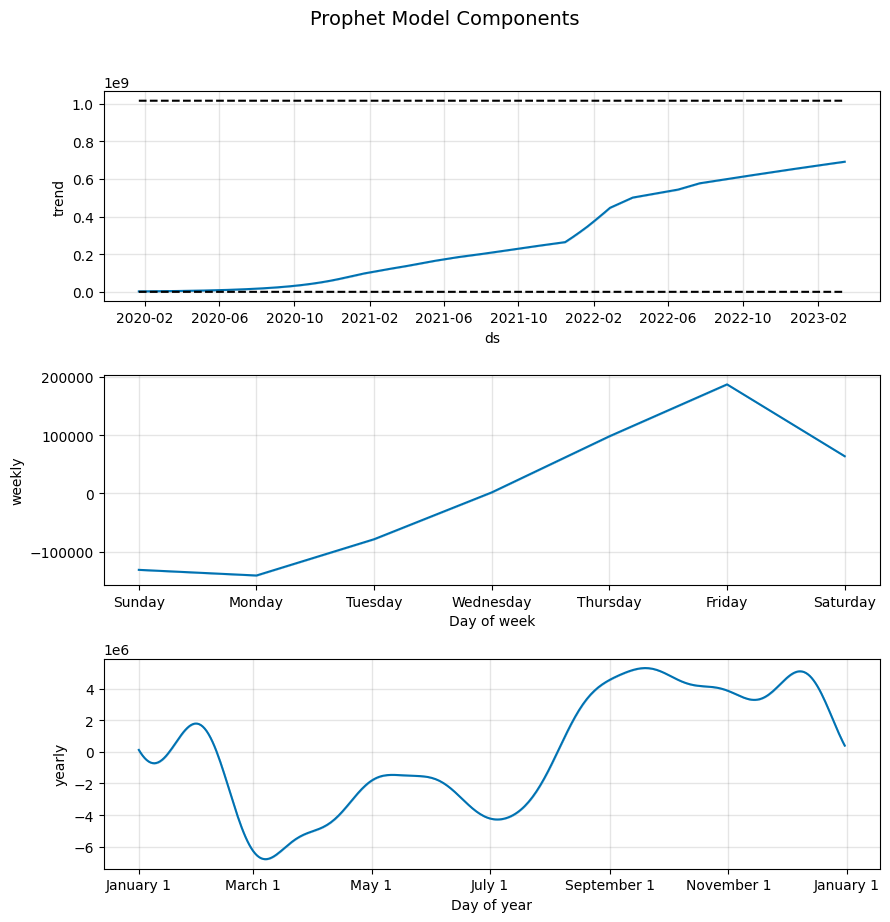

In [13]:
# Prophet built-in component plots (trend + seasonality)
fig_comp = m.plot_components(forecast)
import matplotlib.pyplot as plt
plt.suptitle('Prophet Model Components', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 📋 Step 10 — 7-Day Forecast Table

In [14]:
pred_table = future_fc[['ds','yhat','yhat_lower','yhat_upper']].copy()
pred_table.columns = ['Date','Predicted Cases','Lower Bound','Upper Bound']
pred_table['Date'] = pred_table['Date'].dt.strftime('%Y-%m-%d')
for col in ['Predicted Cases','Lower Bound','Upper Bound']:
    pred_table[col] = pred_table[col].apply(lambda x: f'{int(x):,}')

print('📋 7-Day COVID-19 Forecast (Global Confirmed Cases)\n')
print(pred_table.to_string(index=False))

📋 7-Day COVID-19 Forecast (Global Confirmed Cases)

      Date Predicted Cases Lower Bound Upper Bound
2023-03-10     681,612,746 677,272,314 686,137,316
2023-03-11     681,995,035 677,279,273 686,497,162
2023-03-12     682,320,168 678,113,354 686,727,476
2023-03-13     682,842,953 678,564,860 687,243,476
2023-03-14     683,447,453 679,130,325 688,021,800
2023-03-15     684,077,334 679,460,381 688,565,076
2023-03-16     684,727,993 680,546,090 689,533,641


## 📊 Step 11 — Recovery vs Fatality Rate Comparison

In [15]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Global Recovery & Fatality Rate', 'India Recovery & Fatality Rate'])

for col_idx, (df, label) in enumerate([(global_df,'Global'),(india_df,'India')], start=1):
    fig.add_trace(go.Scatter(
        x=df['date'], y=df['recovery_rate'],
        name=f'{label} Recovery %', line=dict(color='#2A9D8F'),
        showlegend=(col_idx==1)
    ), row=1, col=col_idx)
    fig.add_trace(go.Scatter(
        x=df['date'], y=df['fatality_rate'],
        name=f'{label} Fatality %', line=dict(color='#E63946'),
        showlegend=(col_idx==1)
    ), row=1, col=col_idx)

fig.update_layout(
    title='💉 Recovery Rate vs Case Fatality Rate Over Time',
    height=450, template='plotly_white', hovermode='x unified'
)
fig.show()

## ✅ Summary

| Step | What we did |
|------|-------------|
| 1 | Installed & imported pandas, plotly, prophet |
| 2 | Loaded Johns Hopkins CSSE COVID-19 dataset |
| 3 | Visualized global cumulative trend |
| 4 | Plotted daily new cases with 7-day rolling average |
| 5 | Built India-specific 4-panel dashboard |
| 6 | Ranked top-10 countries by confirmed cases |
| 7 | Rendered choropleth world map |
| 8 | Trained Facebook Prophet time-series model |
| 9 | Visualized 7-day ahead forecast with confidence bands |
| 10 | Printed forecast table |
| 11 | Compared recovery vs fatality rates |

---
*End of analysis*